In [1]:
# Example loading and plotting lidar data of Hybrid Dune Campaign

import numpy as np
import xarray as xr
import os   
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from netCDF4 import Dataset

import sys
sys.path.append('./functions')
from convert_lidar_coordinates_ds_single import convert_lidar_coordinates_ds


In [2]:
def filter_pointcloud(nc_in, n_lidar, n_storm, t_sel=None, profile_isel=None):
    # Example loading and filtering lidar data of Hybrid Dune Campaign

    # Define frame angles to be skipped
    # Initialize the array: shape (3, 2, 4, 3)
    hoek_frame_skip = np.zeros((3, 2, 4, 3))
    # S1
    hoek_frame_skip[:, :, 0, 0] = [[-17.4, -14.9], [-13.8, -10.9], [-2.75, 0]]   # storm 1
    hoek_frame_skip[:, :, 0, 1] = [[-16.9, -13.9], [-13.3, -9.9], [-2.25, 0.5]]  # storm 2
    hoek_frame_skip[:, :, 0, 2] = [[-17.4, -14.4], [-13.8, -10.9], [-2.75, 0]]   # storm 3

    # S2
    hoek_frame_skip[:, :, 1, 0] = [[-21.2, -18.2], [-14.3, -11.3], [-2.3, 0.7]]
    hoek_frame_skip[:, :, 1, 1] = [[-20.2, -17.7], [-13.8, -10.8], [-1.3, 1.7]]
    hoek_frame_skip[:, :, 1, 2] = [[-21.2, -18.2], [-14.3, -11.8], [-2.3, 0.7]]

    # S3
    hoek_frame_skip[:, :, 2, 0] = [[-17.0, -14.5], [-12.5, -9.5], [1.0, 4.0]]
    hoek_frame_skip[:, :, 2, 1] = [[-17.0, -14.5], [-12.5, -9.5], [1.0, 4.0]]
    hoek_frame_skip[:, :, 2, 2] = [[-17.5, -14.5], [-12.5, -10.0], [0.5, 4.0]]

    # S4
    hoek_frame_skip[:, :, 3, 0] = [[-19.25, -16.25], [-11.25, -8.75], [-2.75, 0.25]]
    hoek_frame_skip[:, :, 3, 1] = [[-19.25, -16.25], [-11.25, -8.75], [-2.75, 0.25]]
    hoek_frame_skip[:, :, 3, 2] = [[-19.75, -16.75], [-11.75, -8.75], [-3.25, -0.25]]

    # # determine limits to load data from: which vertical angles to select. Between -90° and 105°
    # ds = xr.open_dataset(nc_in).isel(profile_number=0, t=0, echos=0)   # select specific time range: t0 until t_end

    # # # find obs_number with -90° < beam_angle < 105°
    # i_obs_start = np.where(ds.beam_angle.values > -90)[0][0]
    # i_obs_end = np.where(ds.beam_angle.values < 93)[0][-1]
    # print(i_obs_end)

    i_obs_start = 360  # set manually, always the same if looking for the same angles.Here: straight under lidar
    i_obs_end = 545 # for 93deg

    # load data with these obs_number limits
    if (t_sel is  None) and (profile_isel is None):
        ds = xr.open_dataset(nc_in).isel(obs_number=slice(i_obs_start, i_obs_end))                                            # select specific angles
    elif t_sel is None:
        ds = xr.open_dataset(nc_in).isel(profile_number=profile_isel, obs_number=slice(i_obs_start, i_obs_end))               # select specific angles and profile
    elif profile_isel is None:
        ds = xr.open_dataset(nc_in).sel(t=t_sel).isel(obs_number=slice(i_obs_start, i_obs_end))                               # select specific angles and time range
    else:
        ds = xr.open_dataset(nc_in).sel(t=t_sel).isel(profile_number=profile_isel, obs_number=slice(i_obs_start, i_obs_end))  # select specific angles, profile and time range

    # Filter out the frame -----------------------------------------------------------------------
    # Filter out the frame by replacing values in ds.beam_angle with NaN where the laser sees the frame. Then use filtered beam angles for coordianate conversion.

    # Select the slice for given n_lidar and n_storm (Python: 0-based)
    # Example: n_lidar = 1, n_storm = 2 (MATLAB) -> Python: 0, 1
    hoek_frame_skip_slice = hoek_frame_skip[:, :, n_lidar-1, n_storm-1] 

    # Filter frame: loop, for every row in hoek_frame_skip_slice, make angles nan where angles>value_col_1 and angles<value_col_2
    angles = ds.beam_angle.values

    for row in hoek_frame_skip_slice:
        angles[(angles > row[0]) & (angles < row[1])] = np.nan

    ds.beam_angle.values = angles   

    # Convert to local coordinates
    ds = convert_lidar_coordinates_ds(ds, 'local', max_echos=True, keep_I=False, keep_r=True, keep_y=False) # skip intensity, take max distance of echos

    # Define skip area (to remove points below x=6m and above z=-1m)
    x_skip_area = 6.5   # delete every point that is less than 6 m landward of lidar, and (simultaneously) less than 1 m below the lidar
    z_skip_area = -1
    x_min = ds.x_i_local.values + x_skip_area
    z_max = ds.z_i.values + z_skip_area

    # make x, y, z values nan where (x < x_skip_area) & (z > z_skip_area)
    mask_keep = (ds.x.values > x_min) | (ds.z.values < z_max) # keep where either condition is met. So remove where <x_lmin and >z_max
    ds['x'] = ds.x.where(mask_keep)
    #ds['y'] = ds.y.where(mask_keep)
    ds['z'] = ds.z.where(mask_keep)
    ds['radius_lidar'] = ds.radius_lidar.where(mask_keep)

    return ds


In [3]:
# LOAD POINTCLOUD AND FILTER DATA
# INPUT PARAMETERS ------------------------------------------------------------------------------------------------
n_lidar = 2  # set as needed (1-based, like MATLAB)

for n_storm in [1, 2, 3]:
#n_storm = 1 # set as needed (1-based, like MATLAB)

    nc_in = fr"O:\HybridDune experiment\data lidar netcdf\storm{n_storm}_lidar{n_lidar}_polar - new.nc"
    nc_in = fr"C:\Users\dpoppema\OneDrive - Delft University of Technology\dataset_hybrid_dune\Lidar\data\S{n_lidar} Lidar, storm{n_storm}.nc"

    if n_storm == 1:
        t1 = pd.Timestamp('19-12-2024 00:00') # was 2:00
        t2 = pd.Timestamp('20-12-2024 00:09') # was 19dec 22:00
    elif n_storm == 2:
        t1 = pd.Timestamp('22-12-2024 04:00')
        t2 = pd.Timestamp('22-12-2024 23:09')
    elif n_storm == 3:
        t1 = np.datetime64('2025-01-01T12:00')
        t2 = np.datetime64('2025-01-02T09:09')  # ensure that Jan 2 is selected, not Feb 1
    else:
        raise ValueError('n_storm must be 1, 2, or 3')

    # LOAD AND FILTER POINTCLOUD ----------------------------------------------------------------------------------------
    #ds.close()
    ds = filter_pointcloud(nc_in, n_lidar, n_storm, t_sel=slice(t1, t2), profile_isel=2) # Filter out frame and high waves (points less than 1 m below lidar and offshore of dune toe)
    ds = ds.drop_vars(['x','z'])

    # EXTRACT DUNE PROFILES FROM POINTCLOUDS ----------------------------------------------------------------------------
    # take moving max radius over X minutes, ignore NaNs
    dt_minutes = 10
    window_length = np.int16(dt_minutes * 60 * ds.sf.values) # 5 minutes * 60 seconds * 4 Hz
    ds['radius_lidar'] = ds.radius_lidar.rolling(t=window_length, center=True, min_periods=1).max()   # min_periods=1: 1 non-nan value is enough. So A) ignore nans and b) ignore window edges

    # Select one point cloud per window: For each instant in time_vector, select the first t >= time_vector[i]
    #time_vector = pd.date_range(start=t1, end=t2, freq=f'{dt_minutes}min')
    time_vector = pd.date_range(start=t1, end=t2, freq='20min')

    t_vals = pd.to_datetime(ds.t.values)
    selected_indices = []
    for t_ref in time_vector:
        idx = np.searchsorted(t_vals, t_ref, side='left')
        if idx < len(t_vals):
            selected_indices.append(idx)

    ds_plot = ds.isel(t=selected_indices)

    # Remove outliers: make r nan where the difference between consecutive r values over dim obs_number is larger than 0.5 m
    mask_full = xr.DataArray(np.ones_like(ds_plot.radius_lidar, dtype=bool), dims=ds_plot.radius_lidar.dims, coords=ds_plot.radius_lidar.coords)  # pre-define mask: size of ds.radius_lidar, true everywhere
    r_diff = ds_plot.radius_lidar.diff(dim='obs_number')                     # Calculate the difference between consecutive values
    mask = np.abs(r_diff) <= 0.5                                        # Create a mask: True where the difference is <= 0.5, False where it's an outlier
    mask_full.values[1:,:] = mask.values                                # Combine the mask
    ds_plot['radius_lidar'] = ds_plot.radius_lidar.where(mask_full)               # Apply the mask: set outliers to NaN

    # Recalculate x and z, based on the max r per window
    ds_plot = convert_lidar_coordinates_ds(ds_plot, 'local', max_echos=False, keep_I=False, keep_r=False, keep_y=False) # skip intensity, take max distance of echos

    # CALCULATE DUNE VOLUME: THE VOLUME UNDERTHE PROFILE-------------------------------------------------------------------
    # calculate area using shoelace formula
    def polygon_area(x, z):
        return 0.5 * np.abs(np.dot(x, np.roll(z, 1)) - np.dot(z, np.roll(x, 1)))

    # Loop over all t and calculate dune volume for each profile.           V1: x>793--------------------------------------
    volumes = []
    for n_t in range(ds_plot.x.shape[1]):
        x = ds_plot.x[:, n_t].values
        z = ds_plot.z[:, n_t].values

        # filter: select only non-nan x
        mask = ~np.isnan(x)
        x = x[mask]
        z = z[mask]

        # select x, z where x>793 and x<802
        i = (x > 793) & (x < 802)
        x = x[i]
        z = z[i]

        if len(x) == 0:
            volumes.append(np.nan)
            continue
        if (n_storm == 1) & (n_lidar==2):
            x = np.concatenate(( x, [x[-1]+0.3] ))
            z = np.concatenate(( z, [4.79] ))
        elif (n_storm==3) & (n_lidar==2):
            x = np.concatenate((x, [max(800.45, x[-1] + 0.15)]))
            z = np.concatenate((z, [4.85]))
        elif (n_storm==3) & (n_lidar==1):
            x = np.concatenate((x, [min(800.45, x[-1] + 0.47)]))
            z = np.concatenate((z, [4.79]))
                        
        # pad: make a triangle
        x = np.concatenate(([793, 793], x, [802, 802, 793]))
        z = np.concatenate(([1.5, z[0]], z, [z[-1], 1.5, 1.5]))

        # Calculate dune volume
        area = polygon_area(x, z)
        volumes.append(area)

    # Calculate erosion_volume: 0 for t=0, then difference in volume for all subsequent steps
    volumes = np.array(volumes)
    erosion_volume = np.zeros_like(volumes)
    erosion_volume[:-1] = volumes[:-1] - volumes[1:] # erosion at time t is V(t) - V(t+1). Or -E = dV = V(t+1)-V(t)

    # Assign erosion_volume to ds for every t, with attribute 'Units' = 'm3/m'
    ds_plot['erosion_volume1'] = (('t',), erosion_volume)
    ds_plot['erosion_volume1'].attrs['Units'] = 'm3/m'

    # Loop over all t and calculate dune volume for each profile.           V2: z>2---------------------------------------
    volumes = []
    for n_t in range(ds_plot.x.shape[1]):
        x = ds_plot.x[:, n_t].values
        z = ds_plot.z[:, n_t].values

        # filter: select only non-nan x
        mask = ~np.isnan(x)
        x = x[mask]
        z = z[mask]

        # select x, z where x>793 and x<802
        i = (z > 2) & (x < 802)
        x = x[i]
        z = z[i]

        if len(x) == 0:
            volumes.append(np.nan)
            continue
        if (n_storm == 1) & (n_lidar==2):
            x = np.concatenate(( x, [x[-1]+0.3] ))
            z = np.concatenate(( z, [4.79] ))
        elif (n_storm==3) & (n_lidar==2):
            x = np.concatenate((x, [min(800.45, x[-1] + 0.15)]))
            z = np.concatenate((z, [4.85]))
        elif (n_storm==3) & (n_lidar==1):
            x = np.concatenate((x, [min(800.45, x[-1] + 0.47)]))
            z = np.concatenate((z, [4.79]))
            
        # pad: make a triangle
        x = np.concatenate(( [x[0]], x, [802,   802, x[0]] ))
        z = np.concatenate(( [2],    z, [z[-1], 2,   2   ] ))

        # Calculate dune volume
        area = polygon_area(x, z)
        volumes.append(area)

    # Calculate erosion_volume: 0 for t=0, then difference in volume for all subsequent steps
    volumes = np.array(volumes)
    erosion_volume = np.zeros_like(volumes)
    erosion_volume[:-1] = volumes[:-1] - volumes[1:]

    # Assign erosion_volume to ds for every t, with attribute 'Units' = 'm3/m'
    ds_plot['dune_volume'] = (('t',), volumes)
    ds_plot['dune_volume'].attrs['Units'] = 'm3/m'
    ds_plot['erosion_volume2'] = (('t',), erosion_volume)
    ds_plot['erosion_volume2'].attrs['Units'] = 'm3/m'
    print("Erosion volumes assigned to ds['erosion_volume'].")

    if n_storm == 1:
        ds1a=ds_plot.copy()
    elif n_storm == 2:
        ds2a=ds_plot.copy()
    elif n_storm == 3:
        ds3a=ds_plot.copy()

Erosion volumes assigned to ds['erosion_volume'].
Erosion volumes assigned to ds['erosion_volume'].
Erosion volumes assigned to ds['erosion_volume'].


In [4]:
# Add hydrodynamic data from RBR netcdf file --------------------------------------------------------
n_lidar=1
for n_storm in [1, 2, 3]:
    # Select lidar dataset 
    if n_storm == 1:
        ds_plot = ds1a.copy()
        t1 = pd.Timestamp('19-12-2024 00:00') # was 2:00
        t2 = pd.Timestamp('20-12-2024 00:09') # was 19dec 22:00
    elif n_storm == 2:
        ds_plot = ds2a.copy()
        t1 = pd.Timestamp('22-12-2024 04:00')
        t2 = pd.Timestamp('22-12-2024 23:09')
    elif n_storm == 3:
        ds_plot = ds3a.copy()
        t1 = np.datetime64('2025-01-01T12:00')
        t2 = np.datetime64('2025-01-02T09:09')  # ensure that Jan 2 is selected, not Feb 1
    else:
        raise ValueError('n_storm must be 1, 2, or 3')
    
    if n_storm <= 2:
        nc_rbr = r'C:\Users\dpoppema\OneDrive - Delft University of Technology\dataset_hybrid_dune\Hydrodynamics\Pressure sensors beach and shoreface (BS)\processed\Deployment period 1\Pressure sensor S3 P_BS3 (RBR) processed data - period 1.nc'
    else:
        nc_rbr = r'C:\Users\dpoppema\OneDrive - Delft University of Technology\dataset_hybrid_dune\Hydrodynamics\Pressure sensors beach and shoreface (BS)\processed\Deployment period 2\Pressure sensor S3 P_BS3 (RBR) processed data - period 2.nc'

    ds_rbr = xr.open_dataset(nc_rbr)

    ds_rbr_sel = ds_rbr.sel(t_block=slice(t1, t2))

    # compare the time steps in both datasets
    # Round time values to the nearest 10s to avoid floating point issues
    t_round = pd.to_datetime(ds_plot.t.values).round('10s')
    t_round2 = pd.to_datetime(ds_rbr_sel.t_block.values).round('10s')
    if ~(t_round == t_round2).all():
        # give error
        raise ValueError('Time steps in RBR and Lidar datasets do not match.')

    ds_plot['zs_mean'] = (('t',), ds_rbr_sel.zs_mean.values)
    ds_plot['zs_mean'].attrs = ds_rbr_sel.zs_mean.attrs

    ds_plot['Hm0'] = (('t',), ds_rbr_sel.Hm0.values)
    ds_plot['Hm0'].attrs = ds_rbr_sel.Hm0.attrs

    ds_plot['Tp'] = (('t',), ds_rbr_sel.Tps.values) # Tps: smoothed Tp
    ds_plot['Tp'].attrs = ds_rbr_sel.Tps.attrs

    ds_plot['Tm01'] = (('t',), ds_rbr_sel.Tm01.values) # Tm01: mean wave period
    ds_plot['Tm01'].attrs = ds_rbr_sel.Tm01.attrs

    beta = 0.04  # beach slope, set as needed
    L = (9.81 * ds_plot.Tp**2) / (2 * np.pi)  # deep water wavelength, assuming Tp S3P3 is deep water
    ksi = beta / np.sqrt(ds_plot.Hm0 / L) # irrabaren number
    eta_u = 0.35 * ds_plot.Hm0 * ksi # wave setup
    Sw    = 0.75 * ds_plot.Hm0 * ksi # runup wind waves
    Sig   = 0.06* (ds_plot.Hm0 * L)**0.5  # runup IG waves

    r2procent_A = (1.1 * (eta_u + Sw) + 1.7 * Sig)
    r2procent_B = 0.043 * (ds_plot.Hm0 * L)**0.5

    # r_A is ksi>=0.3, r_B is ksi<0.3
    # r2procent = xr.where(ksi >= 0.3, r2procent_A, r2procent_B)  # skip: huge effect from ksi just above or below 0.3
    r2procent = r2procent_A
    

    ds_plot['ksi'] = ksi
    ds_plot['ksi'].attrs = {'long_name': 'Iribarren number', 'units': '-'}

    ds_plot['r2procent'] =r2procent
    ds_plot['r2procent'].attrs = {'long_name': '2% runup', 'units': 'm above still water level'}

    ds_plot['r2procent_NAP'] = ds_plot.r2procent + ds_plot.zs_mean
    ds_plot['r2procent_NAP'].attrs = {'long_name': '2% runup height in NAP', 'units': 'm NAP'}

    # Assign back to storm datasets
    if n_storm == 1:
        ds1a=ds_plot.copy()
    elif n_storm == 2:
        ds2a=ds_plot.copy()
    elif n_storm == 3:
        ds3a=ds_plot.copy()

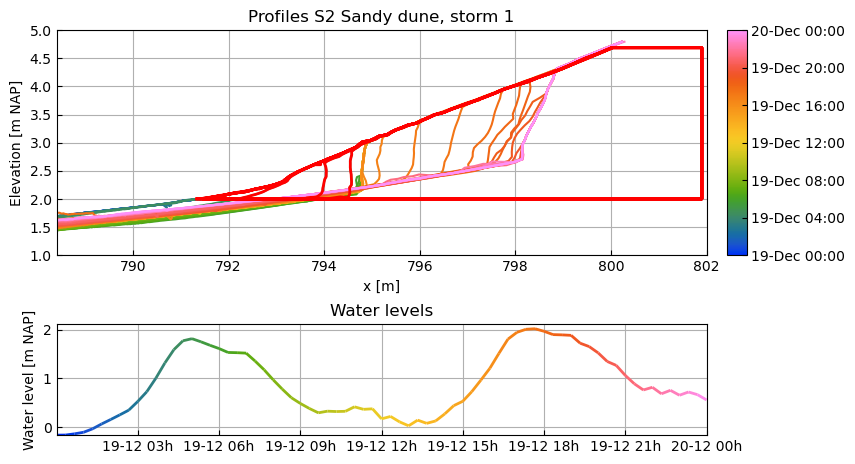

In [6]:
import colorcet as cc   # For color maps
from matplotlib.collections import LineCollection
n_storm = 1
ds_plot = ds1a

# Plot data
x_construction = np.array([803.11, 791.69])
z_construction = np.array([  4.77,   1.07])

# Create two subplots: profiles and waterlevels, manually controlling axes positions for perfect alignment

fig = plt.figure(figsize=(10, 5))

# Define left, width, and heights for both axes (excluding colorbar)
left = 0.1
width = 0.65
height1 = 0.45
height2 = 0.2225
bottom1 = 0.45
bottom2 = 0.09

ax1 = fig.add_axes([left, bottom1, width, height1])
ax2 = fig.add_axes([left, bottom2, width, height2])

# Subplot 1: profiles ------------------------------------------------------------------------------
t_vals = pd.to_datetime(ds_plot.t.values)
norm = plt.Normalize(mdates.date2num(t_vals).min(), mdates.date2num(t_vals).max())
cmap = plt.get_cmap('cet_CET_R1')

for i_t, t in enumerate(t_vals):
    color = cmap(norm(mdates.date2num(t)))
    ax1.plot(ds_plot.x[:, i_t], ds_plot.z[:, i_t], marker='o', markersize=0, linestyle='-', color=color)

for i_t, t in enumerate(t_vals):
    x = ds_plot.x[:, i_t].values
    z = ds_plot.z[:, i_t].values
    x = x[~np.isnan(x)]
    z = z[~np.isnan(z)]
    i = (z>2) & (x<802)
    x = x[i]
    z = z[i]
    if (n_storm == 1) & (n_lidar==2):
        x = np.concatenate(( x, [x[-1]+0.3] ))
        z = np.concatenate(( z, [4.79] ))
    elif (n_storm==3) & (n_lidar==2):
        x = np.concatenate((x, [max(800.45, x[-1] + 0.15)]))
        z = np.concatenate((z, [4.85]))
    elif (n_storm==3) & (n_lidar==1):
        x = np.concatenate((x, [x[-1] + 0.47]))
        z = np.concatenate((z, [4.79]))
    x = np.concatenate(([x[0]], x, [801.9, 801.9, x[0]]))
    z = np.concatenate(([2], z, [z[-1], 2, 2]))
    if i_t<17:
        ax1.plot(x, z, marker='x', markersize=0, linestyle='-', color='red', linewidth=2)


# Colorbar for time: add as a separate axis to the right of ax1, not affecting ax2
cbar_left = left + width + 0.02
cbar_width = 0.02
cbar_height = height1
cbar_bottom = bottom1
cax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
n_ticks = 7
tick_locs = np.linspace(mdates.date2num(t_vals).min(), mdates.date2num(t_vals).max(), n_ticks)
tick_labels = [mdates.num2date(t).strftime('%d-%b %H:%M') for t in tick_locs]
cbar.set_ticks(tick_locs)
cbar.set_ticklabels(tick_labels)
# Put all tick marks inside the colorbar
cbar.ax.tick_params(axis='both', direction='in', left=False, right=True)

# labels and limits for profile plot
ax1.set_xlabel('x [m]')
ax1.set_ylabel('Elevation [m NAP]')
ax1.set_title('Profiles S2 Sandy dune, storm 1')
ax1.grid()
ax1.set_xlim(788.4, 802)
ax1.set_ylim(1,5)

# Put all tick marks inside the box for both axes
for ax in [ax1, ax2]:
    ax.tick_params(axis='both', direction='in')

# Subplot 2: waterlevels ------------------------------------------------------------------------------
# Prepare data for colored line
x = pd.to_datetime(ds_plot.t.values)
y = ds_plot.zs_mean.values
x_num = mdates.date2num(x)
points = np.array([x_num, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Use the same norm and cmap as ax1
lc = LineCollection(segments, cmap=cmap, norm=norm)
lc.set_array(x_num)
lc.set_linewidth(2)
ax2.add_collection(lc)
ax2.set_xlim(x.min(), x.max())
ax2.set_ylim(np.nanmin(y), np.nanmax(y)+0.1)
ax2.set_ylabel('Water level [m NAP]')
ax2.set_title('Water levels')
ax2.grid()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %Hh'))
fig.autofmt_xdate()


# export figure as high-res png, tight around the figure
fig_folder = r'C:\Users\dpoppema\OneDrive - Delft University of Technology\PostDoc Hybrid dunes\Conferences\2025 - NCK Themadag'
#fig.savefig(fr'{fig_folder}\dune profiles storm{n_storm}_lidar{n_lidar} volume4.png', dpi=300, bbox_inches='tight')

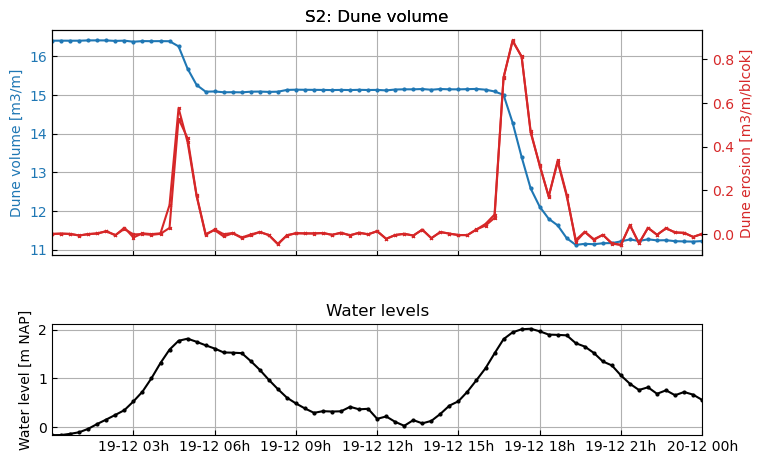

In [24]:
# PLOT DUNE VOLUME AND WATER LEVELS OVER TIME
import matplotlib.dates as mdates
import matplotlib as mpl
fig = plt.figure(figsize=(10, 5))

n_storm = 1
ds_plot = ds1a

# Define left, width, and heights for both axes (excluding colorbar)
left = 0.1
width = 0.65
height1 = 0.45
height2 = 0.2225
bottom1 = 0.45
bottom2 = 0.09

ax1 = fig.add_axes([left, bottom1, width, height1])
ax2 = fig.add_axes([left, bottom2, width, height2])

# Prepare time axis and locator/formatter
x = pd.to_datetime(ds_plot.t.values)
hours = mdates.HourLocator(interval=3)
time_fmt = mdates.DateFormatter('%d-%m %Hh')

# Use default matplotlib muted colors
muted_blue = mpl.colormaps['tab10'](0)  # muted blue
muted_orange = mpl.colormaps['tab10'](1)  # muted orange
muted_green = mpl.colormaps['tab10'](2)   # muted green
muted_red = mpl.colormaps['tab10'](3)   # muted red
muted_purple = mpl.colormaps['tab10'](4)   # muted purple

# Subplot 1: Dune volume and erosion over time
line1, = ax1.plot(x, ds_plot.dune_volume.values, color=muted_blue, marker='o', markersize=2, label='Dune volume')
ax1.set_ylabel('Dune volume [m3/m]', color=muted_blue)
ax1.tick_params(axis='y', labelcolor=muted_blue)
ax1.set_title('S2: Dune volume')

ax1b = ax1.twinx()
line2, = ax1b.plot(x, ds_plot.erosion_volume1.values, color=muted_red, marker='x', markersize=2, label='Dune erosion/block')
line2, = ax1b.plot(x, ds_plot.erosion_volume2.values, color=muted_red, marker='x', markersize=2, label='Dune erosion/block')

ax1b.set_ylabel('Dune erosion [m3/m/blcok]', color=muted_red)
ax1b.tick_params(axis='y', labelcolor=muted_red)
ax1b.set_title('S2: Dune volume')

# line2, = ax1b.plot(x, ds_plot.erosion_volume2.values, color=muted_red, marker='o', markersize=2, label='Erosion')
# ax1b.set_ylabel('Erosion volume [m3/m]', color=muted_red)
# ax1b.tick_params(axis='y', labelcolor=muted_red)
# ax1.set_title('S2: Dune volume and erosion')

# # Add legend to top subplot (top center, two lines)
# lines = [line1, line2]
# labels = [line.get_label() for line in lines]
# ax1.legend(lines, labels, loc='upper right', ncol=1, frameon=True)

# Formatting for ax1 (top subplot)
ax1.grid(True)
ax1.xaxis.set_major_locator(hours)
ax1.xaxis.set_major_formatter(time_fmt)
ax1.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False, direction='in', left=True, right=False)
ax1.tick_params(axis='y', which='both', left=True, right=False, direction='in')

# Subplot 2: Water levels over time
y = ds_plot.zs_mean.values
ax2.plot(x, y, color='black', marker='o', markersize=2, linestyle='-', label='Water level')
ax2.set_xlim(x.min(), x.max())
ax2.set_ylim(np.nanmin(y), np.nanmax(y)+0.1)
ax2.set_ylabel('Water level [m NAP]')
ax2.set_title('Water levels')
ax2.grid(True)
ax2.xaxis.set_major_locator(hours)
ax2.xaxis.set_major_formatter(time_fmt)
ax2.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True, direction='in', left=True, right=False)
ax2.tick_params(axis='y', which='both', left=True, right=False, direction='in')

ax1.set_xlim(ax2.get_xlim())  # Ensure both subplots have the same x-axis limits
fig.autofmt_xdate()


# export figure as high-res png, tight around the figure
fig_folder = r'C:\Users\dpoppema\OneDrive - Delft University of Technology\PostDoc Hybrid dunes\Conferences\2025 - NCK Themadag'
#fig.savefig(fr'{fig_folder}\S2 storm 1, zs vs dune volume 1.png', dpi=300, bbox_inches='tight')

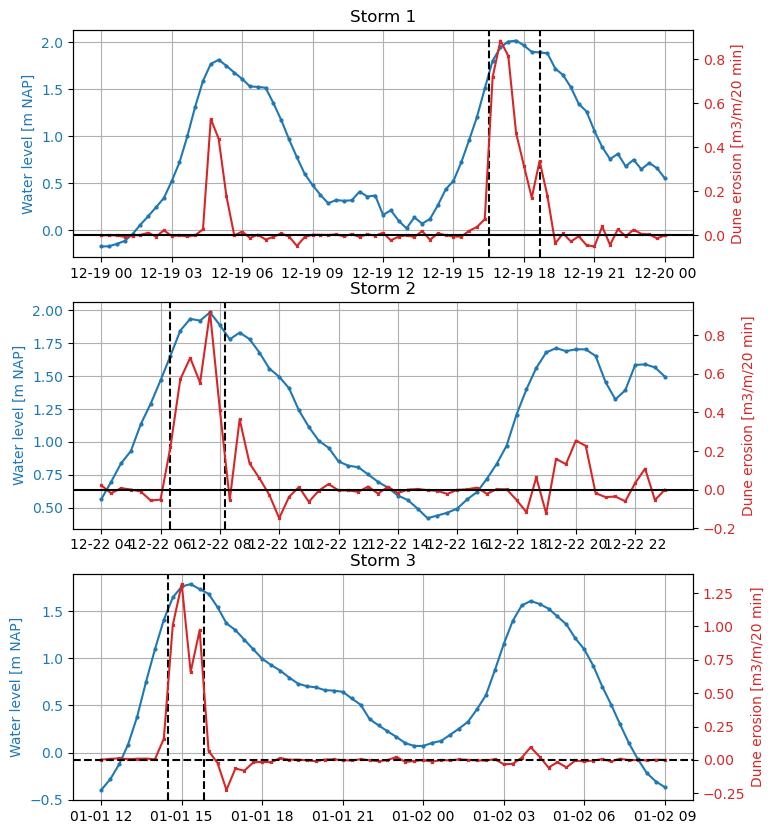

In [70]:
# Make figure with 3 subplots
fig, axs = plt.subplots(3, 1, figsize=(8, 10))


t1 = pd.Timestamp('22-12-2024 04:00')
t2 = pd.Timestamp('22-12-2024 23:09')

t1 = np.datetime64('2025-01-01T12:00')
t2 = np.datetime64('2025-01-02T09:09')  # ensure that Jan 2 is selected, not Feb 1

# Use default matplotlib muted colors
muted_blue = mpl.colormaps['tab10'](0)  # muted blue
muted_orange = mpl.colormaps['tab10'](1)  # muted orange
muted_green = mpl.colormaps['tab10'](2)   # muted green
muted_red = mpl.colormaps['tab10'](3)   # muted red
muted_purple = mpl.colormaps['tab10'](4)   # muted purple

# Subplot 1: storm 1 -------------------------------------------------------------------
ax = axs[0]
ds_plot = ds1a
x = pd.to_datetime(ds_plot.t.values)

t3 = pd.Timestamp('19-12-2024 16:30') 
t4 = pd.Timestamp('19-12-2024 18:40') 

# water level
ax.plot(x, ds_plot.zs_mean.values, color=muted_blue, marker='o', markersize=2, linestyle='-')
ax.set_ylabel('Water level [m NAP]', color=muted_blue)
ax.tick_params(axis='y', labelcolor=muted_blue)
ax.set_title('Storm 1')
ax.axvline(t3,color='black', linestyle='--')
ax.axvline(t4,color='black', linestyle='--')
ax.grid()

# Erosion
ax_b = ax.twinx()
ax_b.plot(x, ds_plot.erosion_volume1.values, color=muted_red, marker='x', markersize=2)
ax_b.set_ylabel('Dune erosion [m3/m/20 min]', color=muted_red)
ax_b.tick_params(axis='y', labelcolor=muted_red)
ax_b.axhline(0,color='black', linestyle='-')

# Subplot 2: storm 2 -------------------------------------------------------------------
ax = axs[1]
ds_plot = ds2a
x = pd.to_datetime(ds_plot.t.values)

t1 = pd.Timestamp('22-12-2024 06:20') 
t2 = pd.Timestamp('22-12-2024 08:10') 

# water level
ax.plot(x, ds_plot.zs_mean.values, color=muted_blue, marker='o', markersize=2, linestyle='-')
ax.set_ylabel('Water level [m NAP]', color=muted_blue)
ax.tick_params(axis='y', labelcolor=muted_blue)
ax.set_title('Storm 2')
ax.axvline(t1,color='black', linestyle='--')
ax.axvline(t2,color='black', linestyle='--')
ax.grid()

# Erosion
ax_b = ax.twinx()
ax_b.plot(x, ds_plot.erosion_volume1.values, color=muted_red, marker='x', markersize=2)
ax_b.set_ylabel('Dune erosion [m3/m/20 min]', color=muted_red)
ax_b.tick_params(axis='y', labelcolor=muted_red)
ax_b.axhline(0,color='black', linestyle='-')

# Subplot 3: storm 3 -------------------------------------------------------------------
ax = axs[2]
ds_plot = ds3a
x = pd.to_datetime(ds_plot.t.values)

t1 = pd.Timestamp('01-01-2025 14:30') 
t2 = pd.Timestamp('01-01-2025 15:50') 

# water level
ax.plot(x, ds_plot.zs_mean.values, color=muted_blue, marker='o', markersize=2, linestyle='-')
ax.set_ylabel('Water level [m NAP]', color=muted_blue)
ax.tick_params(axis='y', labelcolor=muted_blue)
ax.set_title('Storm 3')
ax.axvline(t1,color='black', linestyle='--')
ax.axvline(t2,color='black', linestyle='--')
ax.grid()

# Erosion
ax_b = ax.twinx()
ax_b.plot(x, ds_plot.erosion_volume1.values, color=muted_red, marker='x', markersize=2)
ax_b.set_ylabel('Dune erosion [m3/m/20 min]', color=muted_red)
ax_b.tick_params(axis='y', labelcolor=muted_red)
ax_b.axhline(0,color='black', linestyle='--')



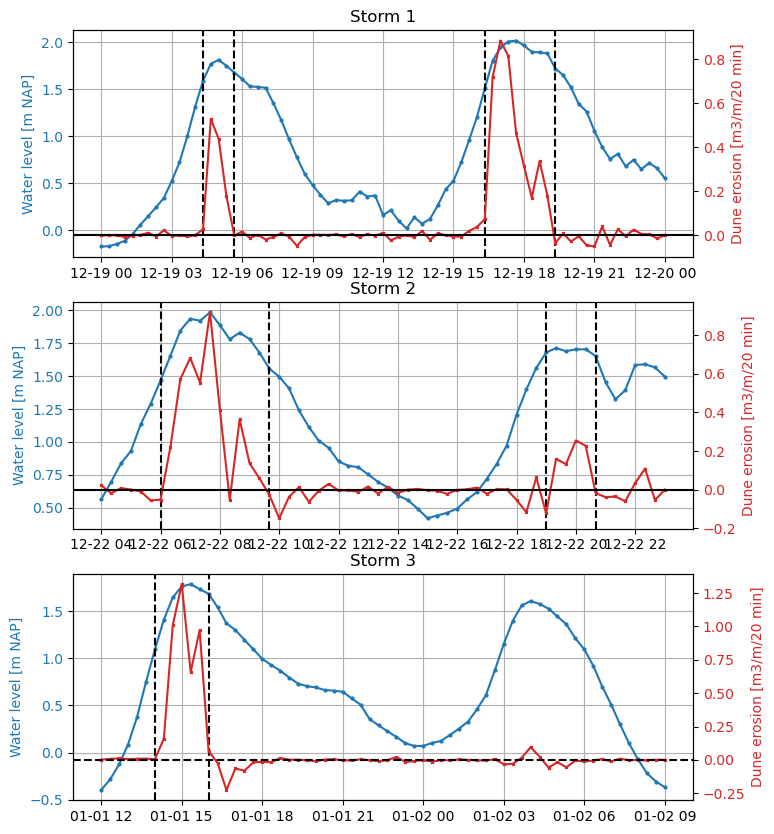

In [66]:
# Make figure with 3 subplots
fig, axs = plt.subplots(3, 1, figsize=(8, 10))


t1 = pd.Timestamp('22-12-2024 04:00')
t2 = pd.Timestamp('22-12-2024 23:09')

t1 = np.datetime64('2025-01-01T12:00')
t2 = np.datetime64('2025-01-02T09:09')  # ensure that Jan 2 is selected, not Feb 1

# Use default matplotlib muted colors
muted_blue = mpl.colormaps['tab10'](0)  # muted blue
muted_orange = mpl.colormaps['tab10'](1)  # muted orange
muted_green = mpl.colormaps['tab10'](2)   # muted green
muted_red = mpl.colormaps['tab10'](3)   # muted red
muted_purple = mpl.colormaps['tab10'](4)   # muted purple

# Subplot 1: storm 1 -------------------------------------------------------------------
ax = axs[0]
ds_plot = ds1a
x = pd.to_datetime(ds_plot.t.values)

t1 = pd.Timestamp('19-12-2024 04:20') 
t2 = pd.Timestamp('19-12-2024 05:40') 
t3 = pd.Timestamp('19-12-2024 16:20') 
t4 = pd.Timestamp('19-12-2024 19:20') 

# water level
ax.plot(x, ds_plot.zs_mean.values, color=muted_blue, marker='o', markersize=2, linestyle='-')
ax.set_ylabel('Water level [m NAP]', color=muted_blue)
ax.tick_params(axis='y', labelcolor=muted_blue)
ax.set_title('Storm 1')
ax.axvline(t1,color='black', linestyle='--')
ax.axvline(t2,color='black', linestyle='--')
ax.axvline(t3,color='black', linestyle='--')
ax.axvline(t4,color='black', linestyle='--')
ax.grid()

# Erosion
ax_b = ax.twinx()
ax_b.plot(x, ds_plot.erosion_volume1.values, color=muted_red, marker='x', markersize=2)
ax_b.set_ylabel('Dune erosion [m3/m/20 min]', color=muted_red)
ax_b.tick_params(axis='y', labelcolor=muted_red)
ax_b.axhline(0,color='black', linestyle='-')

# Subplot 2: storm 2 -------------------------------------------------------------------
ax = axs[1]
ds_plot = ds2a
x = pd.to_datetime(ds_plot.t.values)

t1 = pd.Timestamp('22-12-2024 06:00') 
t2 = pd.Timestamp('22-12-2024 09:40') 
t3 = pd.Timestamp('22-12-2024 19:00') 
t4 = pd.Timestamp('22-12-2024 20:40') 

# water level
ax.plot(x, ds_plot.zs_mean.values, color=muted_blue, marker='o', markersize=2, linestyle='-')
ax.set_ylabel('Water level [m NAP]', color=muted_blue)
ax.tick_params(axis='y', labelcolor=muted_blue)
ax.set_title('Storm 2')
ax.axvline(t1,color='black', linestyle='--')
ax.axvline(t2,color='black', linestyle='--')
ax.axvline(t3,color='black', linestyle='--')
ax.axvline(t4,color='black', linestyle='--')
ax.grid()

# Erosion
ax_b = ax.twinx()
ax_b.plot(x, ds_plot.erosion_volume1.values, color=muted_red, marker='x', markersize=2)
ax_b.set_ylabel('Dune erosion [m3/m/20 min]', color=muted_red)
ax_b.tick_params(axis='y', labelcolor=muted_red)
ax_b.axhline(0,color='black', linestyle='-')

# Subplot 3: storm 3 -------------------------------------------------------------------
ax = axs[2]
ds_plot = ds3a
x = pd.to_datetime(ds_plot.t.values)

t1 = pd.Timestamp('01-01-2025 14:00') 
t2 = pd.Timestamp('01-01-2025 16:00') 


# water level
ax.plot(x, ds_plot.zs_mean.values, color=muted_blue, marker='o', markersize=2, linestyle='-')
ax.set_ylabel('Water level [m NAP]', color=muted_blue)
ax.tick_params(axis='y', labelcolor=muted_blue)
ax.set_title('Storm 3')
ax.axvline(t1,color='black', linestyle='--')
ax.axvline(t2,color='black', linestyle='--')

ax.grid()

# Erosion
ax_b = ax.twinx()
ax_b.plot(x, ds_plot.erosion_volume1.values, color=muted_red, marker='x', markersize=2)
ax_b.set_ylabel('Dune erosion [m3/m/20 min]', color=muted_red)
ax_b.tick_params(axis='y', labelcolor=muted_red)
ax_b.axhline(0,color='black', linestyle='--')

